In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

## Task 1

In [2]:
N=100000
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)


distance_squared = x**2 + y**2
inside_mask = distance_squared <= 1

points_inside = np.sum(inside_mask)
pi_estimate = 4 * points_inside / N

print(f"Estimated Pi: {pi_estimate}")
print(f"Real Pi: {np.pi}")



Estimated Pi: 3.14412
Real Pi: 3.141592653589793


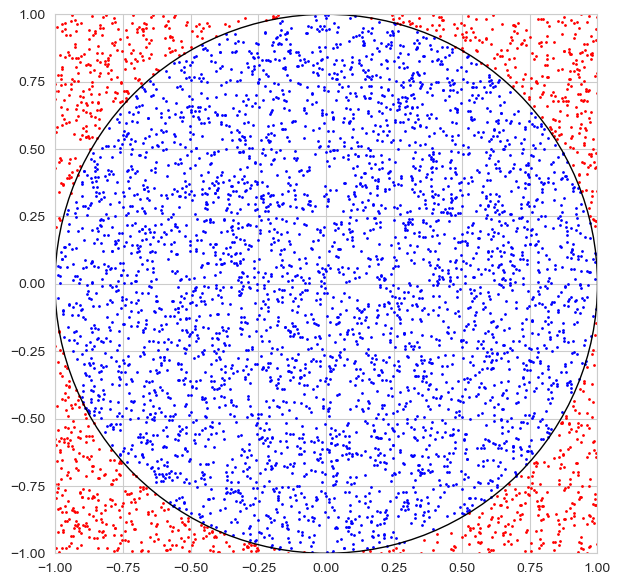

In [3]:
plt.figure(figsize=(7, 7)) 

plt.scatter(x[:5000][inside_mask[:5000]], y[:5000][inside_mask[:5000]], color='blue', s=1) # inside points
plt.scatter(x[:5000][~inside_mask[:5000]], y[:5000][~inside_mask[:5000]], color='red', s=1) # outside points

circle = plt.Circle((0, 0), 1, color='black', fill=False)
plt.gca().add_artist(circle)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.show()


In [4]:
running_inside_count = np.cumsum(inside_mask)

running_pi = 4 * running_inside_count / (np.arange(1, N + 1))

running_pi[99::100]

array([2.88      , 3.        , 3.04      , 3.04      , 3.04      ,
       3.05333333, 3.06857143, 3.105     , 3.11111111, 3.1       ,
       3.07272727, 3.07333333, 3.08923077, 3.09428571, 3.09866667,
       3.095     , 3.09882353, 3.07777778, 3.07789474, 3.086     ,
       3.09333333, 3.10181818, 3.1026087 , 3.095     , 3.0928    ,
       3.08923077, 3.09037037, 3.08285714, 3.09241379, 3.09466667,
       3.09806452, 3.10375   , 3.1030303 , 3.10235294, 3.104     ,
       3.10555556, 3.11027027, 3.10105263, 3.10564103, 3.1       ,
       3.09853659, 3.1       , 3.10790698, 3.10727273, 3.10844444,
       3.11391304, 3.11744681, 3.11916667, 3.11510204, 3.1168    ,
       3.12      , 3.11923077, 3.12      , 3.11703704, 3.11854545,
       3.12      , 3.12140351, 3.11724138, 3.1220339 , 3.12533333,
       3.1252459 , 3.12709677, 3.12825397, 3.131875  , 3.13107692,
       3.12606061, 3.12835821, 3.12588235, 3.12521739, 3.12457143,
       3.12450704, 3.12555556, 3.12547945, 3.12594595, 3.13226

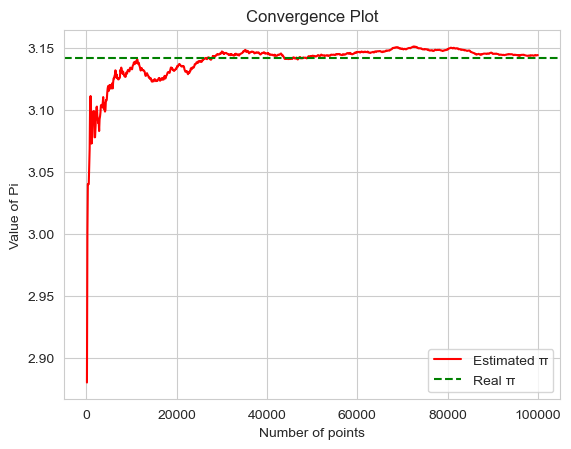

In [5]:
x_axis = np.arange(100, N + 1, 100)
        #x           y
plt.plot(x_axis, running_pi[99::100], color='red', label='Estimated π')

plt.axhline(y=np.pi, color='green', linestyle='--', label='Real π')

plt.title('Convergence Plot')
plt.xlabel('Number of points')
plt.ylabel('Value of Pi')
plt.legend() 
plt.grid(True) 
plt.show()

Approximately after 20000-30000 points, my estimate stabilizes within ±0.01 of true π 

## Task 2

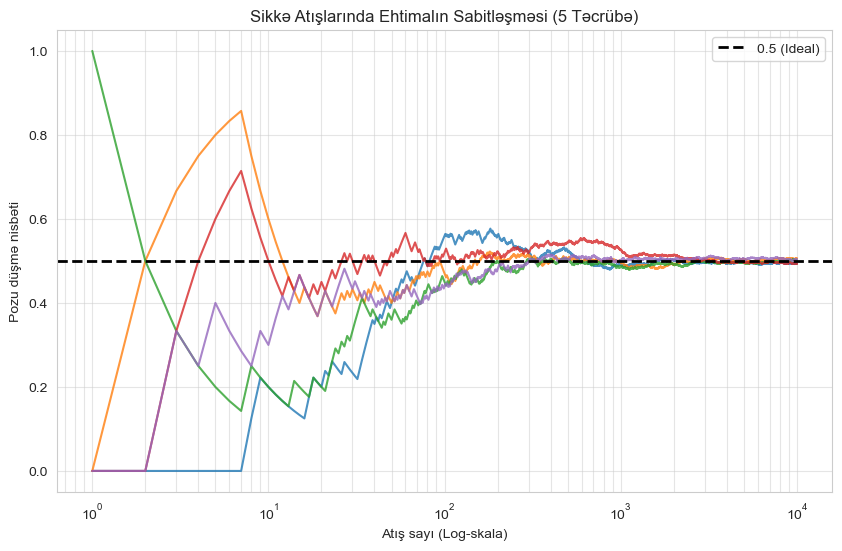

In [6]:
import numpy as np
import matplotlib.pyplot as plt

N = 10000
plt.figure(figsize=(10, 6))

# 5 fərqli təcrübə üçün döngü
for i in range(5):
    # 1. 10,000 atışı bir dəfəyə simulyasiya et
    flips = np.random.binomial(1, 0.5, size=N)
    
    # 2. Running proportion hesablanması
    # Cumulative sum / [1, 2, 3, ..., N]
    cumulative_heads = np.cumsum(flips)
    atish_sayi = np.arange(1, N + 1)
    running_proportion = cumulative_heads / atish_sayi
    
    # 3. Qrafikə əlavə et (hər xətt fərqli rəngdə)
    plt.plot(atish_sayi, running_proportion, alpha=0.8)

# 0.5 səviyyəsində üfüqi xətt
plt.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='0.5 (Ideal)')

# LOG-SCALE tətbiqi (Tapşırığın ən vacib hissəsi)
plt.xscale('log') 

plt.title('Sikkə Atışlarında Ehtimalın Sabitləşməsi (5 Təcrübə)')
plt.xlabel('Atış sayı (Log-skala)')
plt.ylabel('Pozu düşmə nisbəti')
plt.grid(True, which="both", ls="-", alpha=0.5) # Log-skala üçün daha çox dama xətti
plt.legend()
plt.show()

In the first 100 throws, the ratio can be as far out as $0.4$ or $0.6$. Typically, after 1,000 to 2,500 throws, all $5$ lines enter the "safe zone" between $0.49$ and $0.51$ and stabilize there.

## Task 3

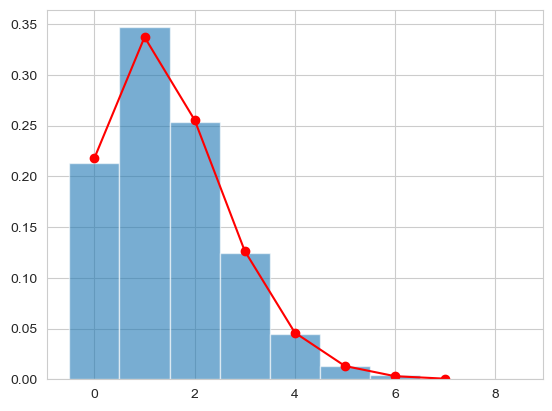

In [7]:
import numpy as np
from scipy.stats import binom

n, p = 50, 0.03
N_batches = 10000

# 10,000 partiyanın hər birindəki xarab sayını yaradır
batch_defects = np.random.binomial(n, p, size=N_batches)
# Histoqram
plt.hist(batch_defects, bins=np.arange(0, 10)-0.5, density=True, alpha=0.6, label='Simulyasiya')

# Nəzəri xətt
x = np.arange(0, 8)
plt.plot(x, binom.pmf(x, n, p), 'ro-', label='Nəzəri (PMF)')

1,000 batches: Will give results close to the expected (theoretical) values, but the graph will look "jagged". The margin of error will be large, especially for rare events (e.g. 5-6 failures in a batch).

10,000 batches: The histogram will almost exactly fit the theoretical PMF line. 10,000 is more reliable for capturing rare events more accurately